<a href="https://colab.research.google.com/github/tarangg0601-arch/employee-salary-prediction/blob/main/Employee_Salary_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import pandas as pd

# Load the dataset
df = pd.read_csv(
    'https://raw.githubusercontent.com/tarangg0601-arch/employee-salary-prediction/main/Salary_Data.csv'
)

# Show first 5 rows
print(df.head())

# Show column names
print("\nColumns:")
print(df.columns.tolist())

# Show dataset size
print("\nDataset Shape:")
print(df.shape)

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

    Age  Gender Education Level          Job Title  Years of Experience  \
0  32.0    Male      Bachelor's  Software Engineer                  5.0   
1  28.0  Female        Master's       Data Analyst                  3.0   
2  45.0    Male             PhD     Senior Manager                 15.0   
3  36.0  Female      Bachelor's    Sales Associate                  7.0   
4  52.0    Male        Master's           Director                 20.0   

     Salary  
0   90000.0  
1   65000.0  
2  150000.0  
3   60000.0  
4  200000.0  

Columns:
['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience', 'Salary']

Dataset Shape:
(6704, 6)

Missing Values:
Age                    2
Gender                 2
Education Level        3
Job Title              2
Years of Experience    3
Salary                 5
dtype: int64


In [27]:
# Check duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Remove duplicate rows
df = df.drop_duplicates()

# Remove rows with missing values
df = df.dropna()

# Check the dataset after cleaning
print("\nDataset after cleaning:")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nMissing values after cleaning:")
print(df.isnull().sum())

Duplicate rows: 4912

Dataset after cleaning:
Rows: 1787
Columns: 6

Missing values after cleaning:
Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64


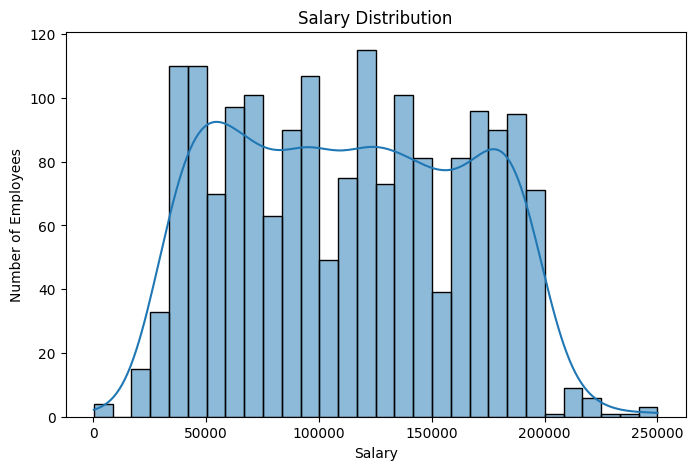

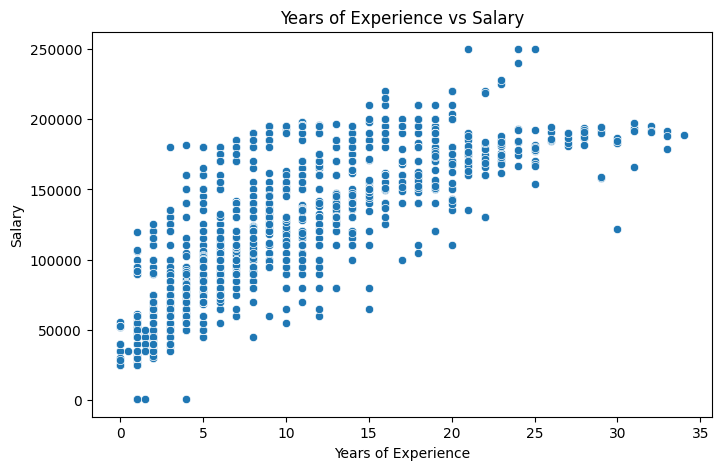

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Salary distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['Salary'], bins=30, kde=True)

plt.title('Salary Distribution')
plt.xlabel('Salary')
plt.ylabel('Number of Employees')
plt.show()


# Experience vs Salary
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Years of Experience', y='Salary')

plt.title('Years of Experience vs Salary')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()

In [29]:
# Separate features and target

X = df.drop('Salary', axis=1)
y = df['Salary']

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

# Convert categorical columns into numerical columns
X_encoded = pd.get_dummies(X, drop_first=True)

print("\nEncoded data shape:", X_encoded.shape)
print("\nFirst 5 rows of encoded data:")
print(X_encoded.head())

Features:
['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience']

Target:
Salary

Encoded data shape: (1787, 200)

First 5 rows of encoded data:
    Age  Years of Experience  Gender_Male  Gender_Other  \
0  32.0                  5.0         True         False   
1  28.0                  3.0        False         False   
2  45.0                 15.0         True         False   
3  36.0                  7.0        False         False   
4  52.0                 20.0         True         False   

   Education Level_Bachelor's Degree  Education Level_High School  \
0                              False                        False   
1                              False                        False   
2                              False                        False   
3                              False                        False   
4                              False                        False   

   Education Level_Master's  Education Level_Master's Degree  \
0  

In [30]:
from sklearn.model_selection import train_test_split

# Split the encoded data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training data: (1429, 200)
Testing data: (358, 200)
Training target: (1429,)
Testing target: (358,)


In [31]:
from sklearn.linear_model import LinearRegression

# Create the Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Model trained successfully!")


Model trained successfully!


In [32]:
# Make predictions on the test data
y_pred = model.predict(X_test)

# Display actual vs predicted salaries
results = pd.DataFrame({
    'Actual Salary': y_test.values,
    'Predicted Salary': y_pred
})

print(results.head(10))

   Actual Salary  Predicted Salary
0       155000.0     137174.617412
1        55000.0      64146.089673
2        50000.0      43366.818340
3        95000.0     108927.121178
4       130000.0     144519.632875
5       154990.0     150989.833747
6       170000.0     126795.260405
7       120000.0     115591.632280
8        50000.0      41174.399592
9        40000.0      34651.729514


In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Evaluation")
print("-----------------")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Model Evaluation
-----------------
Mean Absolute Error (MAE): 15741.89
Root Mean Squared Error (RMSE): 21483.39
R² Score: 0.8316


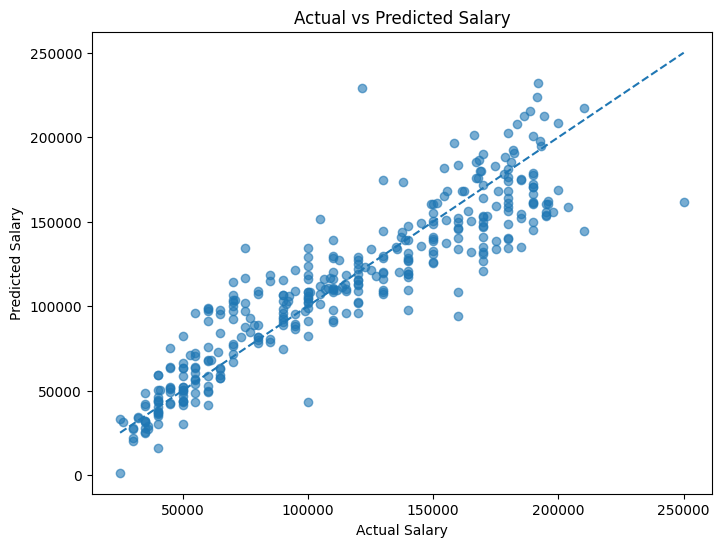

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

# Perfect prediction reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.title('Actual vs Predicted Salary')

plt.show()

In [35]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# Get available values from the dataset
genders = sorted(df['Gender'].unique())
education_levels = sorted(df['Education Level'].unique())
job_titles = sorted(df['Job Title'].unique())

# Create input widgets
age_widget = widgets.IntSlider(
    value=25,
    min=int(df['Age'].min()),
    max=int(df['Age'].max()),
    step=1,
    description='Age:'
)

gender_widget = widgets.Dropdown(
    options=genders,
    description='Gender:'
)

education_widget = widgets.Dropdown(
    options=education_levels,
    description='Education:'
)

job_widget = widgets.Dropdown(
    options=job_titles,
    description='Job Title:'
)

experience_widget = widgets.FloatSlider(
    value=3,
    min=float(df['Years of Experience'].min()),
    max=float(df['Years of Experience'].max()),
    step=0.5,
    description='Experience:'
)

predict_button = widgets.Button(
    description='Predict Salary',
    button_style='success'
)

output = widgets.Output()

def predict_salary(b):
    with output:
        clear_output()

        new_employee = pd.DataFrame({
            'Age': [age_widget.value],
            'Gender': [gender_widget.value],
            'Education Level': [education_widget.value],
            'Job Title': [job_widget.value],
            'Years of Experience': [experience_widget.value]
        })

        new_employee_encoded = pd.get_dummies(
            new_employee,
            drop_first=True
        )

        new_employee_encoded = new_employee_encoded.reindex(
            columns=X_train.columns,
            fill_value=0
        )

        predicted_salary = model.predict(new_employee_encoded)[0]

        print("Employee Details")
        print("----------------")
        print(f"Age: {age_widget.value}")
        print(f"Gender: {gender_widget.value}")
        print(f"Education: {education_widget.value}")
        print(f"Job Title: {job_widget.value}")
        print(f"Experience: {experience_widget.value} years")

        print("\n----------------------------")
        print(f"Predicted Salary: {predicted_salary:,.2f}")
        print("----------------------------")

predict_button.on_click(predict_salary)

display(
    age_widget,
    gender_widget,
    education_widget,
    job_widget,
    experience_widget,
    predict_button,
    output
)

IntSlider(value=25, description='Age:', max=62, min=21)

Dropdown(description='Gender:', options=('Female', 'Male', 'Other'), value='Female')

Dropdown(description='Education:', options=("Bachelor's", "Bachelor's Degree", 'High School', "Master's", "Mas…

Dropdown(description='Job Title:', options=('Account Manager', 'Accountant', 'Administrative Assistant', 'Back…

FloatSlider(value=3.0, description='Experience:', max=34.0, step=0.5)

Button(button_style='success', description='Predict Salary', style=ButtonStyle())

Output()

In [36]:
import pickle

# Save the trained model
with open('salary_model.pkl', 'wb') as file:
    pickle.dump(model, file)

print("Model saved successfully!")

Model saved successfully!


In [37]:
with open('model_columns.pkl', 'wb') as file:
    pickle.dump(X_train.columns.tolist(), file)

print("Model columns saved successfully!")

Model columns saved successfully!
